# Advanced Numpy, Librosa, and Neural Networks Assignment
This assignment will guide you through advanced Numpy operations, basic and advanced usage of Librosa for audio processing, Fourier transforms, Butterworth filtering, and the creation of a simple Artificial Neuron using Python classes and objects.

## Part 1: Audio Signal Processing
In this section, you will learn how to load an audio file, perform Fourier Transform to analyze the signal in the frequency domain, apply a Butterworth filter, and visualize the results.

In [2]:
!pip install numpy librosa scipy matplotlib
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display


   ---------------------------------------- 0.0/260.1 kB ? eta -:--:--
   ----------------------------- ---------- 194.6/260.1 kB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 260.1/260.1 kB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/64.6 kB ? eta -:--:--
   ---------------------------------------- 64.6/64.6 kB ? eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------  1.0/1.0 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 10.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/166.7 kB ? eta -:--:--
   ---------------------------------------- 166.7/166.7 kB 9.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Load the Audio Data
Use `librosa` to load the given audio file and visualize the waveform.

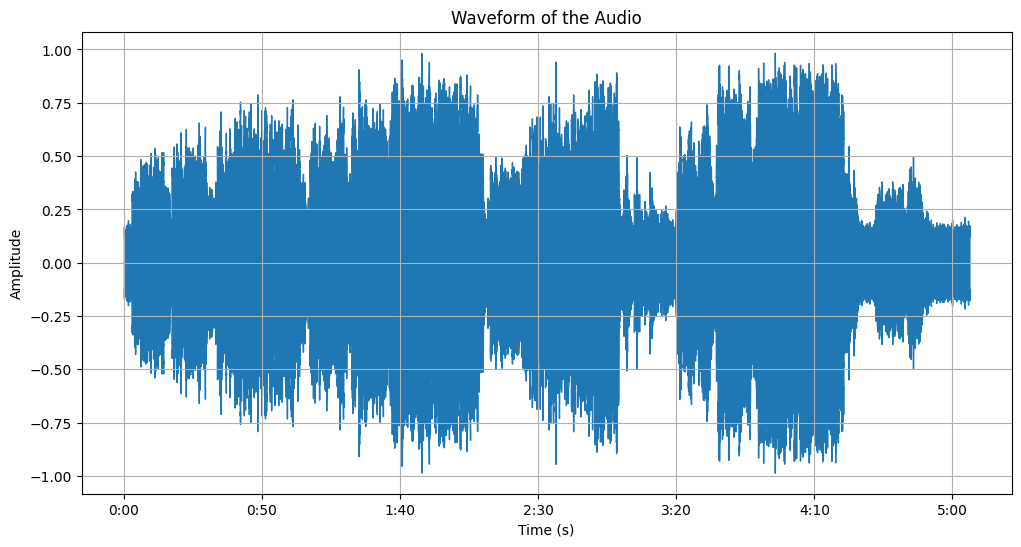

In [6]:
# Load the audio file 
audio_file = r'C:\Users\shash\WIDS24\week1\sample_audio.wav'

y, sr = librosa.load(audio_file, sr=None)

# Plot the signal
plt.figure(figsize=(12, 6))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform of the Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### Step 2: Perform Fourier Transform
Use Numpy's `fft` function to perform Fourier Transform on the audio signal and plot its frequency spectrum.

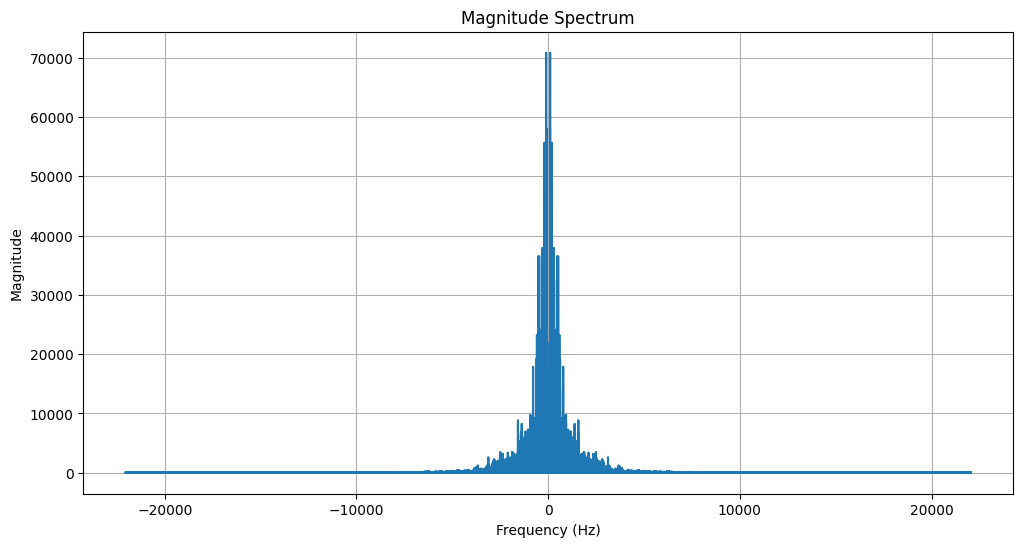

In [7]:
# Perform Fourier Transform on the signal
Y =np.fft.fft(y) # finding fft
# Get frequency bins
frequencies =np.fft.fftfreq(len(Y),d=1/sr) # axis for freq
# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(Y))#you can only choose the postive frequencies if you want to as fft is symmetric about y-axis 
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()
# Code goes here

### Step 3: Apply a Butterworth Filter
Use a Butterworth filter to remove unwanted frequencies and plot the filtered signal, and save the audio as a .wav file, using the `soundfile` package.

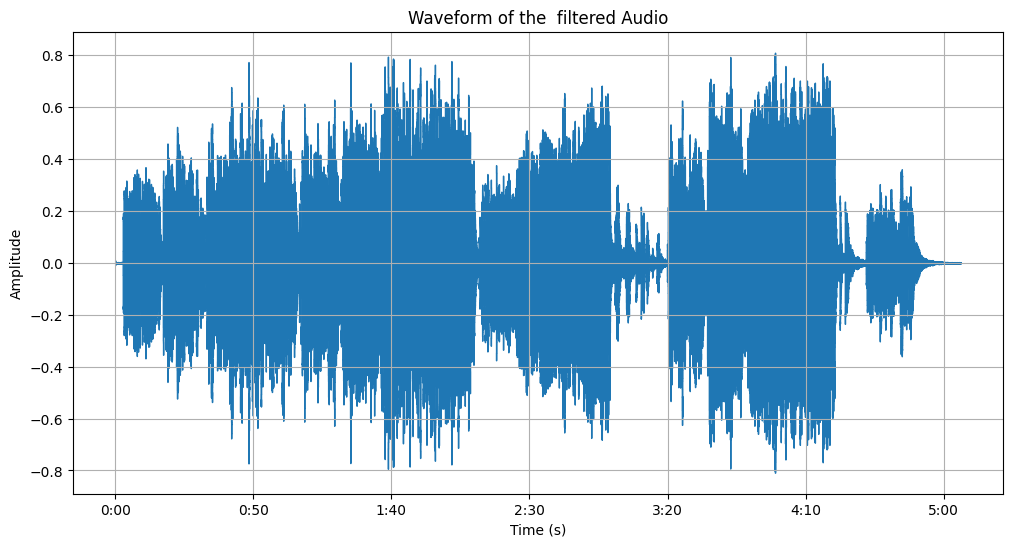

In [8]:

import soundfile as sf
from scipy.signal import butter, filtfilt


def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

cutoff_frequency =500 # Use the best cutoff frequency that you get by trial and error
order = 6
# Filter the audio
b, a = butter_lowpass(cutoff_frequency, sr, order=order)
y_filtered = filtfilt(b, a, y)


sf.write("audio.wav", y_filtered, sr)




# Plot filtered audio signal
plt.figure(figsize=(12, 6))
librosa.display.waveshow(y_filtered, sr=sr)
plt.title('Waveform of the  filtered Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


### Step 4: Fourier Transform of the Filtered Signal
Apply Fourier Transform on the filtered signal and visualize the spectrum to compare it with the original signal.

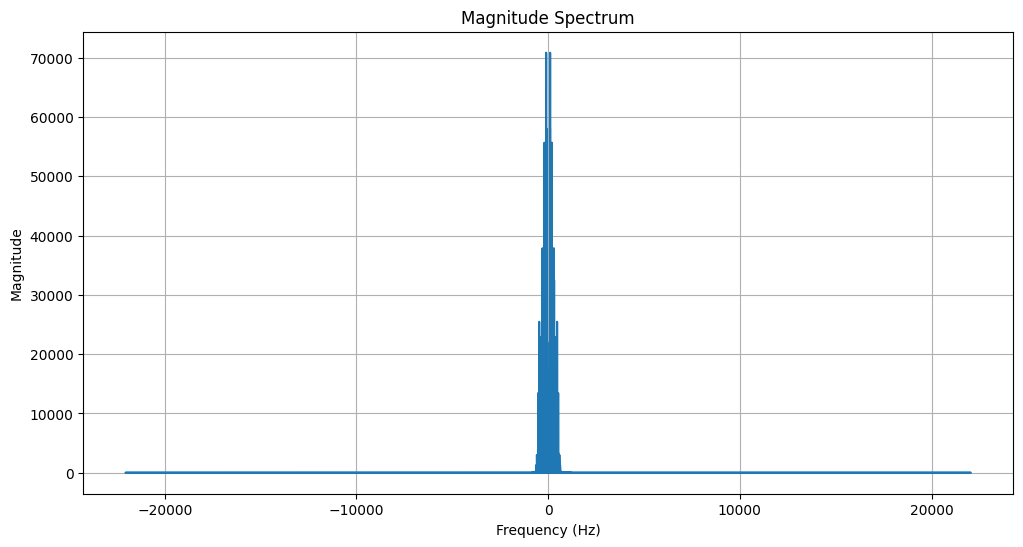

In [9]:
Y_filtered=np.fft.fft(y_filtered) 
frequencies_filtered=np.fft.fftfreq(len(Y_filtered),d=1/sr) 
plt.figure(figsize=(12, 6))
plt.plot(frequencies_filtered, np.abs(Y_filtered))
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

## Part 2: Implementing a Simple Artificial Neuron
In this section, you will implement a basic Artificial Neuron using Python classes and objects.

In [10]:
import numpy as np
# Define a simple neuron class
class Neuron:
    def __init__(self, num_inputs, weights):
        if(len(weights)!=num_inputs):
            raise ValueError("Number of weights must match the number of inputs")
        self.weights=weights
        self.bias=0
                                                      
    def sigmoid(self, x):
       return 1/(1+np.exp(-x))
    def feedforward(self, inputs):
      t=np.dot(self.weights,inputs)+self.bias
      return self.sigmoid(t)

# Test the Neuron
weights = np.array([0.2, 0.4, 0.4])
neuron = Neuron(3, weights)
inputs = np.array([0.5, 0.3, 0.8])
output = neuron.feedforward(inputs)
print('Output from the neuron:'), output

Output from the neuron:


(None, 0.6318124177361016)

### [Additional]
This is an implementation of a simple training function using gradient descent to update the weights and bias of the neuron.

In [11]:
class Neuron:
    def __init__(self, num_inputs, learning_rate=0.1):
        self.weights = np.random.rand(num_inputs)
        self.bias = np.random.rand(1)
        self.learning_rate = learning_rate
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    def sigmoid_derivative(self, x):
        return x * (1 - x)
    def feedforward(self, inputs):
        self.inputs = inputs
        self.total_input = np.dot(inputs, self.weights) + self.bias
        self.output = self.sigmoid(self.total_input)
        return self.output
    def train(self, inputs, expected_output, epochs=1000):
        for epoch in range(epochs):
            output = self.feedforward(inputs)
            error = expected_output - output
            derror = error * self.sigmoid_derivative(output)
            self.weights += self.learning_rate * derror * inputs
            self.bias += self.learning_rate * derror